**First Steps**

# LinkedIn Salary Prediction Project

**Student:** Goudarz Javadizadeh

**Student Number:** 25220901017

**Course:** Data Mining

**Methodology:** Multivariate Linear Regression & PCA

### 1. Data Loading and Initial Exploration
I begin by loading the dataset and inspecting its central tendencies.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate, KFold

# Load the dataset
df = pd.read_csv('postings.csv')

# Basic Statistical Description
print("Dataset Shape:", df.shape)
print(df[['med_salary', 'views', 'applies']].describe())

Dataset Shape: (123849, 31)
          med_salary          views       applies
count    6280.000000  122160.000000  23320.000000
mean    22015.619876      14.618247     10.591981
std     52255.873846      85.903598     29.047395
min         0.000000       1.000000      1.000000
25%        18.940000       3.000000      1.000000
50%        25.500000       4.000000      3.000000
75%      2510.500000       8.000000      8.000000
max    750000.000000    9975.000000    967.000000


### 2. Data Pre-processing
According to Lecture, data quality is paramount. I am:
* **Handling Missing Values:** Removing records without a target variable (`med_salary`).
* **Feature Selection:** Dropping high-cardinality text columns (descriptions, 
job_posting_url, application_url and skills_desc) to reduce noise.

In [27]:
# Dropping irrelevant/noisy columns
cols_to_drop = ['description', 'job_posting_url', 'application_url', 'skills_desc']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Completeness check: Remove rows where the target is missing
df = df.dropna(subset=['med_salary'])

# Fill remaining numerical NaNs with 0 to maintain consistency
df = df.fillna(0)

### 3. Feature Engineering
I am applying two key techniques from Lecture:
1. **Target Transformation:** Applying a Log transformation to normalize the skewed salary distribution.
2. **Feature Encoding:** Converting categorical metadata into numerical labels for the regression model.

In [ ]:
# Target Transformation
df['log_salary'] = np.log1p(df['med_salary'])

# Feature Encoding
encoders = {}

cat_cols = ['formatted_work_type', 'location', 'formatted_experience_level', 'pay_period', 'work_type']

for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

print("Encoders saved for:", encoders.keys())

# Define Features (X) and Target (y)
features = ['formatted_work_type', 'location', 'formatted_experience_level', 'pay_period', 'views', 'applies', 'remote_allowed']
X = df[features]
y = df['log_salary']

Encoders saved for: dict_keys(['formatted_work_type', 'location', 'formatted_experience_level', 'pay_period', 'work_type'])


### 4. Dimensionality Reduction: PCA
To understand which features describe the most variance and simplify the model, I use PCA. 
I am retaining components that explain 90% of the variance.

In [29]:
# Z-score Normalization is required before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA Implementation
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print(f"Original feature count: {X_scaled.shape[1]}")
print(f"Reduced feature count (PCA): {X_pca.shape[1]}")

Original feature count: 7
Reduced feature count (PCA): 6


### 5. Multivariate Linear Regression & Model Evaluation
I implement the Multivariate Linear Regression model. To ensure the model generalizes 
well and avoids overfitting, I use 5-Fold Cross-Validation.

In [30]:
# Initialize K-Fold and Model
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr_model = LinearRegression()

# Evaluation
cv_results = cross_validate(lr_model, X_pca, y, cv=kf, 
                            scoring=['r2', 'neg_mean_squared_error'])

# Results Output
mean_r2 = cv_results['test_r2'].mean()
mean_rmse = np.sqrt(abs(cv_results['test_neg_mean_squared_error'].mean()))

print(f"Mean R-Squared (R2): {mean_r2:.4f}")
print(f"Mean RMSE: {mean_rmse:.4f}")

Mean R-Squared (R2): 0.9408
Mean RMSE: 0.8415


### 6. Visualizing Results
A visual comparison of actual vs. predicted values helps verify the linear relationship.

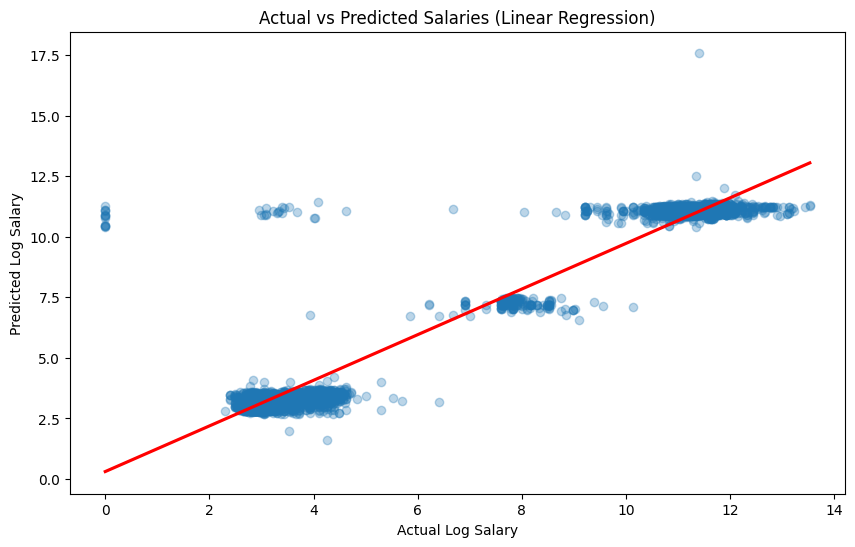

In [33]:
plt.figure(figsize=(10,6))
sns.regplot(x=y, y=lr_model.fit(X_pca, y).predict(X_pca), scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Actual Log Salary')
plt.ylabel('Predicted Log Salary')
plt.title('Actual vs Predicted Salaries (Linear Regression)')
plt.show()

### 7. Deployment: Salary Predictor
This section allows for real-time prediction by passing new job attributes through the established pipeline (Scaling -> PCA -> Regression -> Inverse Log).

In [37]:
# Assume i have a new job: 

# 1. Define the new job using real words
new_location = "New York, NY"
new_work_type = "Full-time"
new_exp_level = "Entry level"

# 2. Look up the numbers using the SPECIFIC encoder for each column
work_num = encoders['formatted_work_type'].transform([new_work_type])[0]
loc_num  = encoders['location'].transform([new_location])[0]
exp_num  = encoders['formatted_experience_level'].transform([new_exp_level])[0]

new_job_data = np.array([[work_num, loc_num, exp_num, 0, 500, 20, 1]])

# Step A: Standardize
new_job_scaled = scaler.transform(new_job_data)

# Step B: Reduce Dimensions
new_job_pca = pca.transform(new_job_scaled)

# Step C: Predict
predicted_log_salary = lr_model.predict(new_job_pca)

# Step D: Reverse the Log Transformation
# Since i used log(x+1), i use exp(x)-1 to get the real value
actual_salary_pred = np.expm1(predicted_log_salary)

print(f"The predicted annual salary is: ${actual_salary_pred[0]:,.2f}")

The predicted annual salary is: $65.62


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
